<a href="https://colab.research.google.com/github/BitanS2000/News-Sentiment-vs-Market-Volatility-Tracker/blob/main/News_Sentiment_vs_Market_Volatility_Tracker.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import yfinance as yf

In [ ]:
import finnhub
import datetime
import time
import pytz

In [ ]:
from transformers import pipeline

In [ ]:
ai_portfolio = {
    "NVDA": "Hardware (Chips)",
    "AMD": "Hardware (Chips)",
    "MSFT": "Software/Cloud",
    "GOOGL": "Software/Cloud",
    "TSM": "Infrastructure",
    "AVGO": "Infrastructure",
}

tickers = list(ai_portfolio.keys())

In [ ]:
print("Fetching stock data from Yahoo Finance...")
raw_data = yf.download(tickers, period="6mo", group_by="ticker")

Fetching stock data from Yahoo Finance...


/tmp/ipykernel_10386/547293482.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  raw_data = yf.download(tickers, period="6mo", group_by="ticker")
[*********************100%***********************]  6 of 6 completed


In [ ]:
processed_frames = []

In [ ]:
for ticker in tickers:
    df_ticker = raw_data[ticker].copy()
    df_ticker["Ticker"] = ticker
    df_ticker["Category"] = ai_portfolio[ticker]

    df_ticker["Daily_Return"] = df_ticker["Close"].pct_change()

    df_ticker["Rolling_Volatility"] = (
        df_ticker["Daily_Return"].rolling(window=5).std()
    )

    df_ticker = df_ticker.reset_index()

    columns_to_keep = [
        "Date",
        "Ticker",
        "Category",
        "Close",
        "Volume",
        "Daily_Return",
        "Rolling_Volatility",
    ]
    processed_frames.append(df_ticker[columns_to_keep])

In [ ]:
master_stock_df = pd.concat(processed_frames, ignore_index=True)

master_stock_df = master_stock_df.dropna()

print("\n Stock Data Successfully Retrieved and Structured!")
master_stock_df.head(10)


 Stock Data Successfully Retrieved and Structured!


Price,Date,Ticker,Category,Close,Volume,Daily_Return,Rolling_Volatility
5,2026-01-14,NVDA,Hardware (Chips),182.916901,159586100,-0.014370,0.011086
6,2026-01-15,NVDA,Hardware (Chips),186.822128,206188600,0.021350,0.012852
7,2026-01-16,NVDA,Hardware (Chips),186.003128,187967200,-0.004384,0.013152
8,2026-01-20,NVDA,Hardware (Chips),177.853088,223345300,-0.043817,0.024274
9,2026-01-21,NVDA,Hardware (Chips),183.096695,200381000,0.029483,0.029339
10,2026-01-22,NVDA,Hardware (Chips),184.614822,139636600,0.008291,0.028762
11,2026-01-23,NVDA,Hardware (Chips),187.441376,142748100,0.015311,0.027869
12,2026-01-26,NVDA,Hardware (Chips),186.242844,124799600,-0.006394,0.027980
13,2026-01-27,NVDA,Hardware (Chips),188.290344,143711600,0.010994,0.012929
14,2026-01-28,NVDA,Hardware (Chips),191.286682,148552700,0.015913,0.009068


In [ ]:
master_stock_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 708 entries, 5 to 737
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Date                708 non-null    datetime64[ns]
 1   Ticker              708 non-null    object        
 2   Category            708 non-null    object        
 3   Close               708 non-null    float64       
 4   Volume              708 non-null    int64         
 5   Daily_Return        708 non-null    float64       
 6   Rolling_Volatility  708 non-null    float64       
dtypes: datetime64[ns](1), float64(3), int64(1), object(2)
memory usage: 44.2+ KB


In [ ]:
master_stock_df.to_csv("ai_stock_data.csv", index=False)

In [ ]:
#!pip install finnhub-python pandas

In [ ]:
FINNHUB_API_KEY = "d92gop1r01qnksfej2vgd92gop1r01qnksfej300"
finnhub_client = finnhub.Client(api_key=FINNHUB_API_KEY)

tickers = ["NVDA", "AMD", "MSFT", "GOOGL", "TSM", "AVGO"]

end_date = datetime.date.today()
start_date = end_date - datetime.timedelta(days=180)

from_date = start_date.strftime("%Y-%m-%d")
to_date = end_date.strftime("%Y-%m-%d")

news_data = []

print(f"Fetching news from {from_date} to {to_date}...")

Fetching news from 2026-01-07 to 2026-07-06...


In [ ]:
for ticker in tickers:
    print(f"Pulling headlines for {ticker}...")
    try:
        articles = finnhub_client.company_news(ticker, _from=from_date, to=to_date)

        for article in articles:
            news_data.append({
                "Date": datetime.datetime.fromtimestamp(article["datetime"]).strftime('%Y-%m-%d'),
                "Ticker": ticker,
                "Headline": article["headline"],
                "Summary": article["summary"],
                "URL": article["url"]
            })

        time.sleep(2)

    except Exception as e:
        print(f"Error fetching data for {ticker}: {e}")

news_df = pd.DataFrame(news_data)

print("\n News Data Successfully Retrieved and Structured!")
news_df.info()
news_df.head(10)

Pulling headlines for NVDA...
Pulling headlines for AMD...
Pulling headlines for MSFT...
Pulling headlines for GOOGL...
Pulling headlines for TSM...
Pulling headlines for AVGO...

 News Data Successfully Retrieved and Structured!
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1486 entries, 0 to 1485
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Date      1486 non-null   object
 1   Ticker    1486 non-null   object
 2   Headline  1486 non-null   object
 3   Summary   1486 non-null   object
 4   URL       1486 non-null   object
dtypes: object(5)
memory usage: 58.2+ KB


,Date,Ticker,Headline,Summary,URL
0,2026-07-06,NVDA,Explore the top gainers and losers within the ...,Get insights into the dow jones index performa...,https://finnhub.io/api/news?id=aacc08c69cab6b9...
1,2026-07-06,NVDA,Explore the S&P500 index on Monday and find ou...,Let's have a look at what is happening on the ...,https://finnhub.io/api/news?id=7f6dadda73094a7...
2,2026-07-06,NVDA,These stocks are making the most noise in toda...,Curious about the most active stocks on Monday...,https://finnhub.io/api/news?id=b5c829c74f94c16...
3,2026-07-06,NVDA,Nvidia Kyber Rack Reportedly Delayed to 2028,Manufacturing challenges could test Nvidia's r...,https://finnhub.io/api/news?id=0fb64b9a3985b37...
4,2026-07-06,NVDA,The S&P 500 Looks Pricey at 22x Earnings. On C...,"On a recent episode of Barron’s Streetwise, ho...",https://finnhub.io/api/news?id=d81c722f367c50a...
5,2026-07-06,NVDA,First Solar Climbs 5% on Bullish Wells Fargo N...,Solar stocks are ripping higher in Monday trad...,https://finnhub.io/api/news?id=b8053cb4f3373e5...
6,2026-07-06,NVDA,Meta Stock Surged 9% to $612.91 on July 1 Afte...,Meta wants to become more like its hyperscaler...,https://finnhub.io/api/news?id=829057a9c81d2ec...
7,2026-07-06,NVDA,NVDA Stock Climbs Over 1% — Nvidia Says Its AI...,The chipmaker said its product roadmap remains...,https://finnhub.io/api/news?id=4820f3e38333a63...
8,2026-07-06,NVDA,ServiceNow Was the SaaS Stock AI Was Supposed ...,Many analysts now believe ServiceNow (NYSE:NOW...,https://finnhub.io/api/news?id=68951c8c65d3f62...
9,2026-07-06,NVDA,Nvidia’s Biggest Threat Is This: Everyone Is D...,NVIDIA (NASDAQ:NVDA) owns the AI compute marke...,https://finnhub.io/api/news?id=4d1b1ca014068fb...


In [ ]:
news_df.to_csv("ai_news_data.csv", index=False)

In [ ]:
#!pip install transformers torch

In [ ]:
sentiment_pipeline = pipeline("sentiment-analysis", model="ProsusAI/finbert")

def get_sentiment_score(text):

    try:
        result = sentiment_pipeline(text)[0]
        label = result['label']
        confidence = result['score']

        if label == 'positive':
            return confidence
        elif label == 'negative':
            return -confidence
        else:
            return 0.0
    except Exception as e:
        return 0.0

news_df['Sentiment_Score'] = news_df['Headline'].apply(get_sentiment_score)


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

In [ ]:
daily_sentiment_df = news_df.groupby(['Date', 'Ticker'])['Sentiment_Score'].mean().reset_index()
daily_sentiment_df.rename(columns={'Sentiment_Score': 'Daily_Avg_Sentiment'}, inplace=True)

# Convert 'Date' column in daily_sentiment_df to datetime to match master_stock_df
daily_sentiment_df['Date'] = pd.to_datetime(daily_sentiment_df['Date'])

# Corrected line: Use pd.merge() for joining based on keys
final_df = pd.merge(master_stock_df, daily_sentiment_df, on=['Date', 'Ticker'], how='left')

final_df['Daily_Avg_Sentiment'] = final_df['Daily_Avg_Sentiment'].fillna(0.0)

final_df.to_csv("AI_Sector_Master_Data.csv", index=False)

In [ ]:
final_df.tail(10)


,Date,Ticker,Category,Close,Volume,Daily_Return,Rolling_Volatility,Daily_Avg_Sentiment
698,2026-06-22,AVGO,Infrastructure,392.130005,26403700,-0.045216,0.046822,0.000000
699,2026-06-23,AVGO,Infrastructure,380.149994,33122200,-0.030551,0.046819,0.000000
700,2026-06-24,AVGO,Infrastructure,382.070007,29938700,0.005051,0.041778,0.000000
701,2026-06-25,AVGO,Infrastructure,378.910004,23353700,-0.008271,0.035608,0.000000
702,2026-06-26,AVGO,Infrastructure,365.019989,34839300,-0.036658,0.020861,-0.079331
703,2026-06-29,AVGO,Infrastructure,372.450012,24285200,0.020355,0.023895,-0.043524
704,2026-06-30,AVGO,Infrastructure,377.750000,28517400,0.014230,0.022633,0.170076
705,2026-07-01,AVGO,Infrastructure,369.339996,23712600,-0.022263,0.024042,0.016825
706,2026-07-02,AVGO,Infrastructure,360.450012,26749500,-0.024070,0.025333,-0.167476
707,2026-07-06,AVGO,Infrastructure,373.899994,22543419,0.037314,0.027173,0.313622


In [ ]:
final_df.describe()

,Date,Close,Volume,Daily_Return,Rolling_Volatility,Daily_Avg_Sentiment
count,708,708.000000,7.080000e+02,708.000000,708.000000,708.000000
mean,2026-04-09 14:38:38.644067840,334.899560,5.337223e+07,0.002210,0.026436,-0.000484
min,2026-01-14 00:00:00,164.977722,5.884800e+06,-0.173144,0.004031,-0.744278
25%,2026-02-26 00:00:00,253.482498,2.216592e+07,-0.013959,0.016213,0.000000
50%,2026-04-09 12:00:00,345.298035,3.107395e+07,0.000430,0.023080,0.000000
75%,2026-05-21 00:00:00,401.123535,4.506658e+07,0.016864,0.033082,0.000000
max,2026-07-06 00:00:00,580.909973,3.608079e+08,0.186145,0.099783,0.603811
std,NaN,91.629676,5.667896e+07,0.030488,0.015276,0.062457


In [ ]:
# Create a filtered dataframe containing only active news days
active_news_df = final_df[final_df['Daily_Avg_Sentiment'] != 0.0]

print(f"Original trading days: {len(final_df)}")
print(f"Trading days with active news: {len(active_news_df)}")
print(active_news_df['Daily_Avg_Sentiment'].describe())

Original trading days: 708
Trading days with active news: 46
count    46.000000
mean     -0.007455
std       0.247455
min      -0.744278
25%      -0.150524
50%      -0.021860
75%       0.102025
max       0.603811
Name: Daily_Avg_Sentiment, dtype: float64


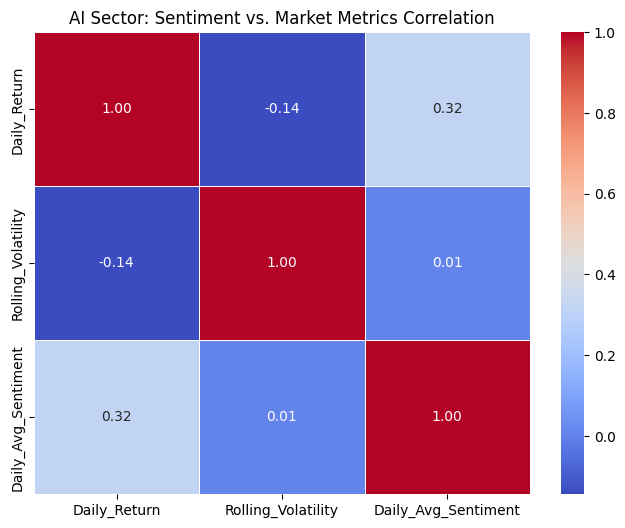

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

analyzable_df = final_df[final_df['Daily_Avg_Sentiment'] != 0.0]

correlation_matrix = analyzable_df[['Daily_Return', 'Rolling_Volatility', 'Daily_Avg_Sentiment']].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('AI Sector: Sentiment vs. Market Metrics Correlation')
plt.show()

In [ ]:
# Create an intensity metric (ignoring if it's positive or negative)
analyzable_df['Sentiment_Intensity'] = analyzable_df['Daily_Avg_Sentiment'].abs()

intensity_corr = analyzable_df['Rolling_Volatility'].corr(analyzable_df['Sentiment_Intensity'])
print(f"Correlation with Sentiment Intensity: {intensity_corr:.2f}")

Correlation with Sentiment Intensity: -0.17


/tmp/ipykernel_10386/1433316222.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  analyzable_df['Sentiment_Intensity'] = analyzable_df['Daily_Avg_Sentiment'].abs()


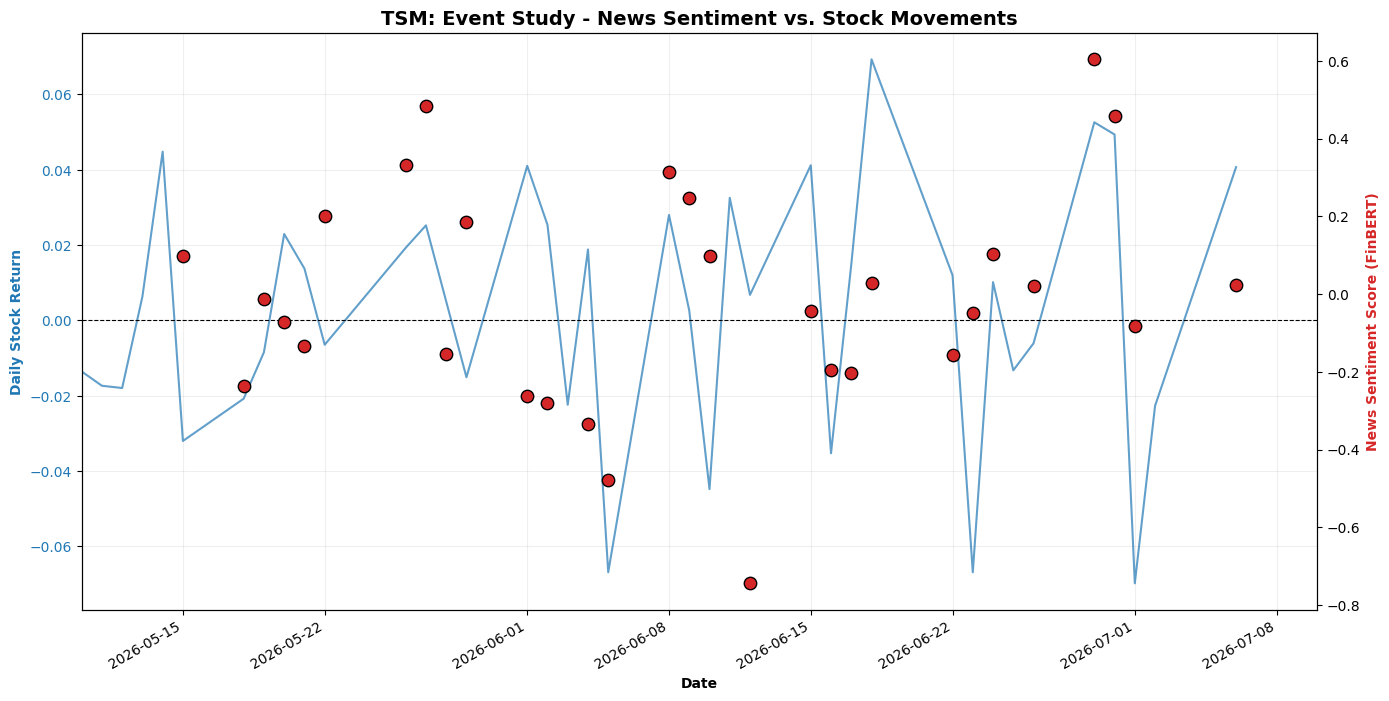

In [ ]:
import matplotlib.pyplot as plt

# 1. Grab ALL NVIDIA data so our timeline (X-axis) is properly sized
nvda_full_df = final_df[final_df['Ticker'] == 'TSM'].sort_values('Date')

# 2. Isolate only the days where actual news happened (for our red dots)
nvda_news_events = nvda_full_df[nvda_full_df['Daily_Avg_Sentiment'] != 0.0]

# 3. Create the plot
fig, ax1 = plt.subplots(figsize=(14, 7))

# Plot Daily Stock Returns (Left Axis - Line Chart is better for full timelines)
color = '#1f77b4'
ax1.set_xlabel('Date', fontweight='bold')
ax1.set_ylabel('Daily Stock Return', color=color, fontweight='bold')
ax1.plot(nvda_full_df['Date'], nvda_full_df['Daily_Return'], color=color, alpha=0.7, label='NVDA Daily Return')
ax1.tick_params(axis='y', labelcolor=color)

# Add a subtle grid and a zero-line to easily see positive vs negative stock days
ax1.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax1.grid(True, alpha=0.2)

# Create a second axis for Sentiment Score
ax2 = ax1.twinx()
color = '#d62728'
ax2.set_ylabel('News Sentiment Score (FinBERT)', color=color, fontweight='bold')

# Plot ONLY the active news days as scatter points (Red dots)
ax2.scatter(nvda_news_events['Date'], nvda_news_events['Daily_Avg_Sentiment'],
            color=color, s=80, edgecolors='black', zorder=5, label='News Event')

# Formatting
plt.title('TSM: Event Study - News Sentiment vs. Stock Movements', fontsize=14, fontweight='bold')
fig.autofmt_xdate() # Automatically rotates dates so they fit nicely
fig.tight_layout()
# Zoom in on the active news window (mid-May to July)
plt.xlim(pd.Timestamp('2026-05-10'), pd.Timestamp('2026-07-10'))
plt.show()

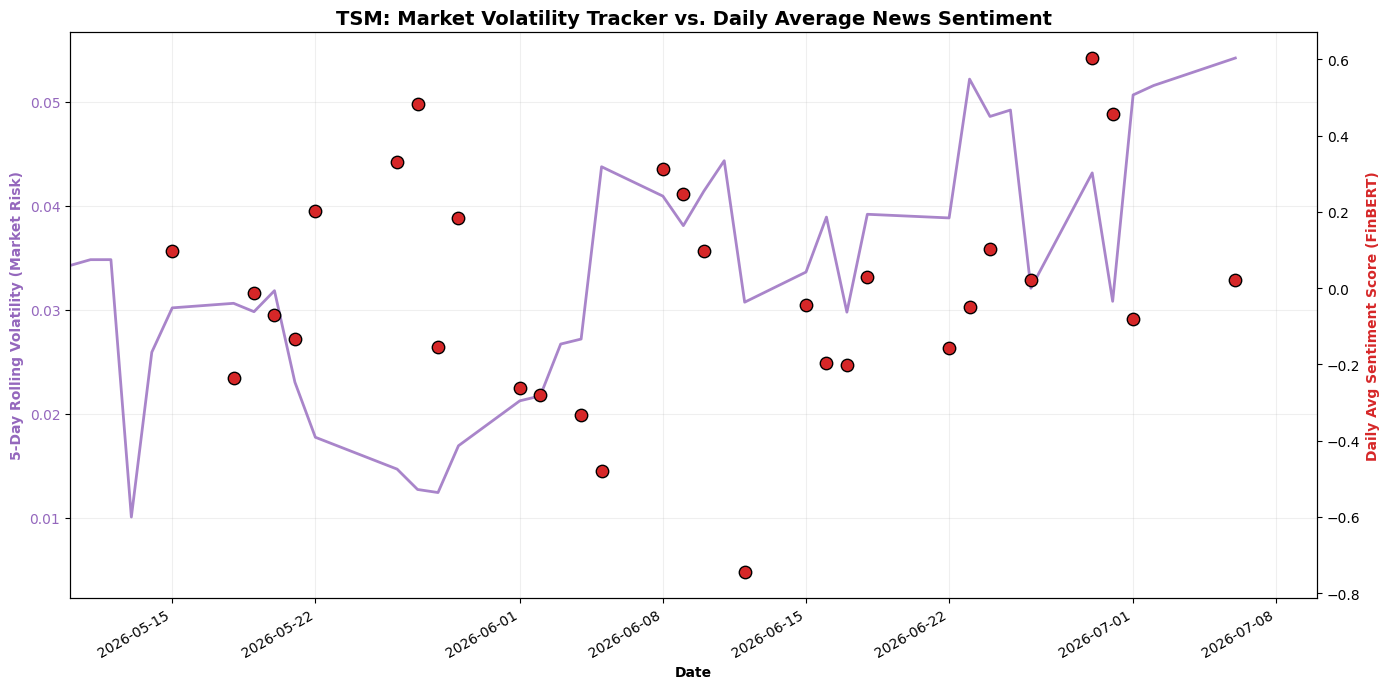

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Isolate the target stock (TSM)
target_ticker = "TSM"
# Ensure the Date column is in datetime format for clean chronological plotting
final_df["Date"] = pd.to_datetime(final_df["Date"])
ticker_full_df = final_df[final_df["Ticker"] == target_ticker].sort_values(
    "Date"
)

# 2. Isolate only the days where actual news happened
ticker_news_events = ticker_full_df[
    ticker_full_df["Daily_Avg_Sentiment"] != 0.0
]

# 3. Create the plot
fig, ax1 = plt.subplots(figsize=(14, 7))

# Plot 5-Day Rolling Volatility (Left Axis - Line Chart)
color_vol = "#9467bd"  # Deep purple for risk/volatility
ax1.set_xlabel("Date", fontweight="bold")
ax1.set_ylabel(
    "5-Day Rolling Volatility (Market Risk)", color=color_vol, fontweight="bold"
)
ax1.plot(
    ticker_full_df["Date"],
    ticker_full_df["Rolling_Volatility"],
    color=color_vol,
    alpha=0.8,
    linewidth=2,
    label="Rolling Volatility",
)
ax1.tick_params(axis='y', labelcolor=color_vol)

# Add a subtle background grid
ax1.grid(True, alpha=0.2)

# Create a second axis for your Average Sentiment Score
ax2 = ax1.twinx()
color_sent = "#d62728"  # Crimson red for sentiment events
ax2.set_ylabel(
    "Daily Avg Sentiment Score (FinBERT)", color=color_sent, fontweight="bold"
)

# Plot the active news days as scatter points
ax2.scatter(
    ticker_news_events["Date"],
    ticker_news_events["Daily_Avg_Sentiment"],
    color=color_sent,
    s=80,
    edgecolors="black",
    zorder=5,
    label="News Event",
)

# Chart Title and Layout Adjustments
plt.title(
    f"{target_ticker}: Market Volatility Tracker vs. Daily Average News Sentiment",
    fontsize=14,
    fontweight="bold",
)
fig.autofmt_xdate()

# Zoom into the exact timeframe where your news events are concentrated
plt.xlim(pd.Timestamp("2026-05-10"), pd.Timestamp("2026-07-10"))

fig.tight_layout()
plt.show()